Imports & License Check

In [25]:
import arcpy
from arcpy import env
from arcpy.sa import *
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Check out Spatial Analyst license
if arcpy.CheckExtension('Spatial') != 'Available':
    raise RuntimeError('Spatial Analyst extension is not available or not licensed.')
arcpy.CheckOutExtension('Spatial')

print('✅ ArcPy', arcpy.GetInstallInfo()['Version'])
print('✅ Spatial Analyst checked out')

✅ ArcPy 3.6.1
✅ Spatial Analyst checked out


User Inputs (EDIT THIS CELL ONLY)

In [26]:
# ── Paths ──────────────────────────────────────────────────────────────
PROJECT_DIR       = r'C:\WatershedProject'
DEM_PATH          = os.path.join(PROJECT_DIR, 'data', 'dem.tif')
POUR_POINT_FC     = os.path.join(PROJECT_DIR, 'data', 'pour_point.shp')
OUTPUT_DIR        = os.path.join(PROJECT_DIR, 'outputs')
GDB_NAME          = 'watershed_analysis.gdb'
GDB_PATH          = os.path.join(OUTPUT_DIR, GDB_NAME)

# ── Analysis parameters ─────────────────────────────────────────────────
SNAP_DISTANCE       = 100    # metres
STREAM_THRESHOLD    = 500    # upslope cells
Z_FACTOR            = 1.0   # use 0.3048 if DEM is in feet and XY is in metres
CURVE_NUMBER        = 75
DESIGN_RAINFALL_MM  = 100.0

# ── Create output folders & GDB ─────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
if not arcpy.Exists(GDB_PATH):
    arcpy.management.CreateFileGDB(OUTPUT_DIR, GDB_NAME)

env.workspace        = GDB_PATH
env.scratchWorkspace = GDB_PATH
env.overwriteOutput  = True
env.snapRaster       = DEM_PATH
env.extent           = DEM_PATH
env.cellSize         = arcpy.Raster(DEM_PATH).meanCellWidth

print('Workspace :', env.workspace)
print('Cell size :', env.cellSize, 'm')

Workspace : C:\WatershedProject\outputs\watershed_analysis.gdb
Cell size : 3.33483239296382E-04 m


Input Validation & DEM Metadata

In [27]:
def rstat(ras, prop):
    """Return a scalar raster property."""
    return float(arcpy.management.GetRasterProperties(ras, prop).getOutput(0))

# Verify inputs exist
for path, label in [(DEM_PATH, 'DEM'), (POUR_POINT_FC, 'Pour point')]:
    if not arcpy.Exists(path):
        raise FileNotFoundError(f'{label} not found: {path}')

# Print DEM metadata
dem_desc = arcpy.Describe(DEM_PATH)
dem_ras  = arcpy.Raster(DEM_PATH)
meta = {
    'CRS'          : dem_desc.spatialReference.name,
    'Cell size (m)': dem_ras.meanCellWidth,
    'Columns'      : dem_ras.width,
    'Rows'         : dem_ras.height,
    'Min elev (m)' : rstat(DEM_PATH, 'MINIMUM'),
    'Max elev (m)' : rstat(DEM_PATH, 'MAXIMUM'),
    'Mean elev (m)': rstat(DEM_PATH, 'MEAN'),
}
print('=== DEM Metadata ===')
for k, v in meta.items():
    print(f'  {k:<18}: {v}')

=== DEM Metadata ===
  CRS               : GCS_WGS_1984
  Cell size (m)     : 0.0003334832392963818
  Columns           : 3013
  Rows              : 974
  Min elev (m)      : 0.0
  Max elev (m)      : 94.0
  Mean elev (m)     : 6.4294953523526


In [28]:
# ── DIAGNOSTIC: Check CRS of DEM and Pour Point ─────────────────────────

print('=' * 55)
print('DEM INFO')
print('=' * 55)
dem_desc = arcpy.Describe(DEM_PATH)
dem_sr   = dem_desc.spatialReference
print(f'  Path        : {DEM_PATH}')
print(f'  Exists      : {arcpy.Exists(DEM_PATH)}')
print(f'  SR object   : {dem_sr}')
print(f'  SR name     : {dem_sr.name if dem_sr else "None"}')
print(f'  Factory code: {dem_sr.factoryCode if dem_sr else "None"}')
print(f'  SR type     : {dem_sr.type if dem_sr else "None"}')
print(f'  Linear unit : {dem_sr.linearUnitName if dem_sr else "None"}')

print()
print('=' * 55)
print('POUR POINT INFO')
print('=' * 55)
pp_desc = arcpy.Describe(POUR_POINT_FC)
pp_sr   = pp_desc.spatialReference
print(f'  Path        : {POUR_POINT_FC}')
print(f'  Exists      : {arcpy.Exists(POUR_POINT_FC)}')
print(f'  File type   : {pp_desc.dataType}')
print(f'  SR object   : {pp_sr}')
print(f'  SR name     : {pp_sr.name if pp_sr else "None"}')
print(f'  Factory code: {pp_sr.factoryCode if pp_sr else "None"}')

print()
print('=' * 55)
print('POUR POINT COORDINATES (first feature)')
print('=' * 55)
with arcpy.da.SearchCursor(POUR_POINT_FC, ['SHAPE@XY']) as cur:
    for row in cur:
        x, y = row[0]
        print(f'  X (Easting / Lon) : {x}')
        print(f'  Y (Northing / Lat): {y}')
        break

print()
print('=' * 55)
print('DEM EXTENT')
print('=' * 55)
ext = arcpy.Describe(DEM_PATH).extent
print(f'  XMin : {ext.XMin}')
print(f'  XMax : {ext.XMax}')
print(f'  YMin : {ext.YMin}')
print(f'  YMax : {ext.YMax}')
print()
print('  ✅ If pour point X/Y falls inside DEM extent → coordinates match.')
print('  ❌ If pour point X/Y is outside DEM extent  → CRS mismatch or wrong file.')

DEM INFO
  Path        : C:\WatershedProject\data\dem.tif
  Exists      : True
  SR object   : <geoprocessing spatial reference object object at 0x000001AF3D32B310>
  SR name     : GCS_WGS_1984
  Factory code: 4326
  SR type     : Geographic
  Linear unit : 

POUR POINT INFO
  Path        : C:\WatershedProject\data\pour_point.shp
  Exists      : True
  File type   : ShapeFile
  SR object   : <geoprocessing spatial reference object object at 0x000001F049532A30>
  SR name     : GCS_WGS_1984
  Factory code: 4326

POUR POINT COORDINATES (first feature)
  X (Easting / Lon) : -97.09202094856113
  Y (Northing / Lat): 36.32399117857597

DEM EXTENT
  XMin : -97.771891
  XMax : -96.767106
  YMin : 36.200663
  YMax : 36.463766

  ✅ If pour point X/Y falls inside DEM extent → coordinates match.
  ❌ If pour point X/Y is outside DEM extent  → CRS mismatch or wrong file.


Hydrology Processing Stack

In [29]:
# Output paths (all inside GDB)
p = lambda name: os.path.join(GDB_PATH, name)

FILLED      = p('filled_dem')
FLOWDIR     = p('flow_direction')
FLOWACC     = p('flow_accumulation')
STR_RAS     = p('stream_raster')
STR_ORDER   = p('stream_order')
STR_FC      = p('stream_network')
PP_PROJ     = p('pour_point_projected')
PP_SNAP     = p('pour_point_snapped')
WS_RAS      = p('watershed_raster')
WS_POLY     = p('watershed_polygon')
STR_CLIP    = p('stream_clipped')
DEM_MASK    = p('dem_masked')
SLOPE       = p('slope_deg')
ASPECT      = p('aspect')

# 4a. Fill sinks — removes depressions so water drains continuously
print('Filling sinks ...')
Fill(DEM_PATH).save(FILLED)

# 4b. Flow direction (D8) — assigns each cell its downslope neighbour
print('Flow direction ...')
FlowDirection(FILLED, 'NORMAL').save(FLOWDIR)

# 4c. Flow accumulation — counts upslope contributing cells per pixel
print('Flow accumulation ...')
FlowAccumulation(FLOWDIR, data_type='INTEGER').save(FLOWACC)

# 4d. Stream raster & Strahler order
print('Stream extraction ...')
SetNull(Raster(FLOWACC) < STREAM_THRESHOLD, 1).save(STR_RAS)
StreamOrder(STR_RAS, FLOWDIR, 'STRAHLER').save(STR_ORDER)
StreamToFeature(STR_ORDER, FLOWDIR, STR_FC, 'SIMPLIFY')

# 4e. Snap pour point to highest-accumulation cell within SNAP_DISTANCE
print('Snapping pour point ...')
dem_sr  = arcpy.Describe(DEM_PATH).spatialReference
arcpy.management.Project(POUR_POINT_FC, PP_PROJ, dem_sr)
oid_fld = arcpy.Describe(PP_PROJ).OIDFieldName
SnapPourPoint(PP_PROJ, FLOWACC, SNAP_DISTANCE, oid_fld).save(PP_SNAP)

# 4f. Watershed delineation
print('Delineating watershed ...')
Watershed(FLOWDIR, PP_SNAP, 'VALUE').save(WS_RAS)
arcpy.conversion.RasterToPolygon(WS_RAS, WS_POLY, 'SIMPLIFY', 'VALUE')

# 4g. Clip streams, mask DEM, compute slope & aspect
print('Clipping streams & computing slope/aspect ...')
arcpy.analysis.Clip(STR_FC, WS_POLY, STR_CLIP)
ExtractByMask(FILLED, WS_POLY).save(DEM_MASK)
Slope(DEM_MASK, 'DEGREE', Z_FACTOR).save(SLOPE)
Aspect(DEM_MASK).save(ASPECT)

print('\n✅ All hydrology rasters complete.')

Filling sinks ...
Flow direction ...
Flow accumulation ...
Stream extraction ...
Snapping pour point ...
Delineating watershed ...
Clipping streams & computing slope/aspect ...

✅ All hydrology rasters complete.


Helper Functions

In [30]:
def add_geom_fields(fc, geom_types):
    """Add AREA_M2 / PERIM_M / LENGTH_M geometry fields via UpdateCursor."""
    for fld, dtype in [('AREA_M2','DOUBLE'),('PERIM_M','DOUBLE'),('LENGTH_M','DOUBLE')]:
        if fld not in [f.name for f in arcpy.ListFields(fc)]:
            arcpy.management.AddField(fc, fld, dtype)
    if 'area' in geom_types:
        with arcpy.da.UpdateCursor(fc, ['SHAPE@AREA','SHAPE@LENGTH','AREA_M2','PERIM_M']) as cur:
            for r in cur:
                r[2], r[3] = r[0], r[1]; cur.updateRow(r)
    if 'length' in geom_types:
        with arcpy.da.UpdateCursor(fc, ['SHAPE@LENGTH','LENGTH_M']) as cur:
            for r in cur:
                r[1] = r[0]; cur.updateRow(r)


def kirpich_tc(L_m, slope_m_per_m):
    """Kirpich (1940) time of concentration — returns Tc in minutes."""
    if slope_m_per_m <= 0:
        return float('nan')
    return 0.0195 * (L_m ** 0.77) * (slope_m_per_m ** -0.385)


def scs_runoff(P_mm, CN):
    """SCS Curve Number — direct runoff Q (mm) for rainfall P (mm)."""
    S  = (25400.0 / CN) - 254.0   # potential max retention (mm)
    Ia = 0.2 * S                   # initial abstraction (20% rule)
    if P_mm <= Ia:
        return 0.0
    return (P_mm - Ia) ** 2 / (P_mm - Ia + S)

print('✅ Helper functions defined.')

✅ Helper functions defined.


Hydrologic Parameter Extraction

In [31]:
params = {}   # main results dictionary

# 6a. Watershed area & perimeter
add_geom_fields(WS_POLY, ['area'])
ws_rows  = list(arcpy.da.SearchCursor(WS_POLY, ['AREA_M2','PERIM_M']))
area_m2  = sum(r[0] for r in ws_rows)
perim_m  = sum(r[1] for r in ws_rows)
area_km2 = area_m2 / 1e6
perim_km = perim_m / 1e3
ext      = arcpy.Describe(WS_POLY).extent
Lb_km    = math.sqrt(ext.width**2 + ext.height**2) / 1e3   # basin length

params['Watershed Area (km²)']  = round(area_km2, 3)
params['Perimeter (km)']        = round(perim_km, 3)
params['Basin Length (km)']     = round(Lb_km, 3)

# 6b. Shape indices
Kc = perim_m / (2 * math.sqrt(math.pi * area_m2))                          # Gravelius compactness
Ff = area_km2 / Lb_km**2 if Lb_km > 0 else float('nan')                    # Form factor (Horton)
Rc = (4 * math.pi * area_m2) / perim_m**2 if perim_m > 0 else float('nan') # Circularity ratio
Re = (2 / Lb_km) * math.sqrt(area_km2 / math.pi) if Lb_km > 0 else float('nan')  # Elongation ratio

params['Compactness Coeff (Kc)'] = round(Kc, 4)
params['Form Factor (Ff)']       = round(Ff, 4)
params['Circularity Ratio (Rc)'] = round(Rc, 4)
params['Elongation Ratio (Re)']  = round(Re, 4)

# 6c. Elevation statistics
e_min  = rstat(DEM_MASK, 'MINIMUM')
e_max  = rstat(DEM_MASK, 'MAXIMUM')
e_mean = rstat(DEM_MASK, 'MEAN')
e_std  = rstat(DEM_MASK, 'STD')
relief = e_max - e_min
Rh = (relief / 1e3) / Lb_km if Lb_km > 0 else float('nan')  # Relief ratio (Schumm 1956)
HI = (e_mean - e_min) / relief if relief > 0 else float('nan')  # Hypsometric integral

params['Min Elevation (m)']     = round(e_min, 2)
params['Max Elevation (m)']     = round(e_max, 2)
params['Mean Elevation (m)']    = round(e_mean, 2)
params['Elevation Relief (m)']  = round(relief, 2)
params['Elev Std Dev (m)']      = round(e_std, 2)
params['Relief Ratio (Rh)']     = round(Rh, 5)
params['Mean Slope (°)']        = round(rstat(SLOPE,'MEAN'), 2)
params['Max Slope (°)']         = round(rstat(SLOPE,'MAXIMUM'), 2)
params['Hypsometric Integral']  = round(HI, 4)

# 6d. Drainage network statistics
add_geom_fields(STR_CLIP, ['length'])
lengths_m    = [r[0] for r in arcpy.da.SearchCursor(STR_CLIP, ['LENGTH_M'])]
total_str_km = sum(lengths_m) / 1e3
n_segments   = len(lengths_m)
Dd = total_str_km / area_km2 if area_km2 > 0 else float('nan')  # Drainage density
Fs = n_segments / area_km2 if area_km2 > 0 else float('nan')    # Stream frequency
T  = n_segments / perim_km  if perim_km  > 0 else float('nan')  # Texture ratio

params['Total Stream Length (km)']  = round(total_str_km, 3)
params['No. Stream Segments']        = n_segments
params['Drainage Density (km/km²)']  = round(Dd, 4)
params['Stream Frequency (1/km²)']   = round(Fs, 4)
params['Texture Ratio']              = round(T, 4)

# 6e. Bifurcation ratio (Strahler)
order_field = next((f.name for f in arcpy.ListFields(STR_CLIP)
                    if f.name.lower() in ('grid_code','gridcode')), None)
order_df = pd.DataFrame()
mean_Rb  = float('nan')
if order_field:
    rows = [(int(r[0]), float(r[1])) for r in
            arcpy.da.SearchCursor(STR_CLIP, [order_field, 'LENGTH_M'])]
    order_df = (
        pd.DataFrame(rows, columns=['Order','Length_m'])
        .groupby('Order')
        .agg(N=('Order','count'),
             TotalLen_km=('Length_m', lambda x: x.sum()/1e3),
             MeanLen_km=('Length_m',  lambda x: x.mean()/1e3))
        .reset_index().sort_values('Order')
    )
    if len(order_df) > 1:
        rb = [order_df.iloc[i]['N'] / order_df.iloc[i+1]['N']
              for i in range(len(order_df)-1)
              if order_df.iloc[i+1]['N'] > 0]
        mean_Rb = float(np.mean(rb)) if rb else float('nan')

params['Mean Bifurcation Ratio (Rb)'] = round(mean_Rb, 3) if not math.isnan(mean_Rb) else 'N/A'

# 6f. Time of concentration & SCS runoff
main_ch_m = max(lengths_m) if lengths_m else Lb_km * 1e3
ch_slope  = relief / main_ch_m if main_ch_m > 0 else float('nan')
Tc_min    = kirpich_tc(main_ch_m, ch_slope)
Q_mm      = scs_runoff(DESIGN_RAINFALL_MM, CURVE_NUMBER)

params['Main Channel Length (m)']     = round(main_ch_m, 1)
params['Time of Concentration (min)'] = round(Tc_min, 2) if not math.isnan(Tc_min) else 'N/A'
params['Curve Number (CN)']           = CURVE_NUMBER
params['Design Rainfall (mm)']        = DESIGN_RAINFALL_MM
params['SCS Direct Runoff Q (mm)']    = round(Q_mm, 2)

# Print full results table
print('\n=== Watershed Parameter Report ===')
for k, v in params.items():
    print(f'  {k:<38}: {v}')


=== Watershed Parameter Report ===
  Watershed Area (km²)                  : 0.0
  Perimeter (km)                        : 0.0
  Basin Length (km)                     : 0.0
  Compactness Coeff (Kc)                : 1.5082
  Form Factor (Ff)                      : 0.2648
  Circularity Ratio (Rc)                : 0.4396
  Elongation Ratio (Re)                 : 0.5807
  Min Elevation (m)                     : 0.0
  Max Elevation (m)                     : 89.0
  Mean Elevation (m)                    : 12.7
  Elevation Relief (m)                  : 89.0
  Elev Std Dev (m)                      : 22.93
  Relief Ratio (Rh)                     : 765.77562
  Mean Slope (°)                        : 9.13
  Max Slope (°)                         : 49.62
  Hypsometric Integral                  : 0.1427
  Total Stream Length (km)              : 0.0
  No. Stream Segments                   : 35
  Drainage Density (km/km²)             : 103443.1075
  Stream Frequency (1/km²)              : 9784343254.2

Visualisations

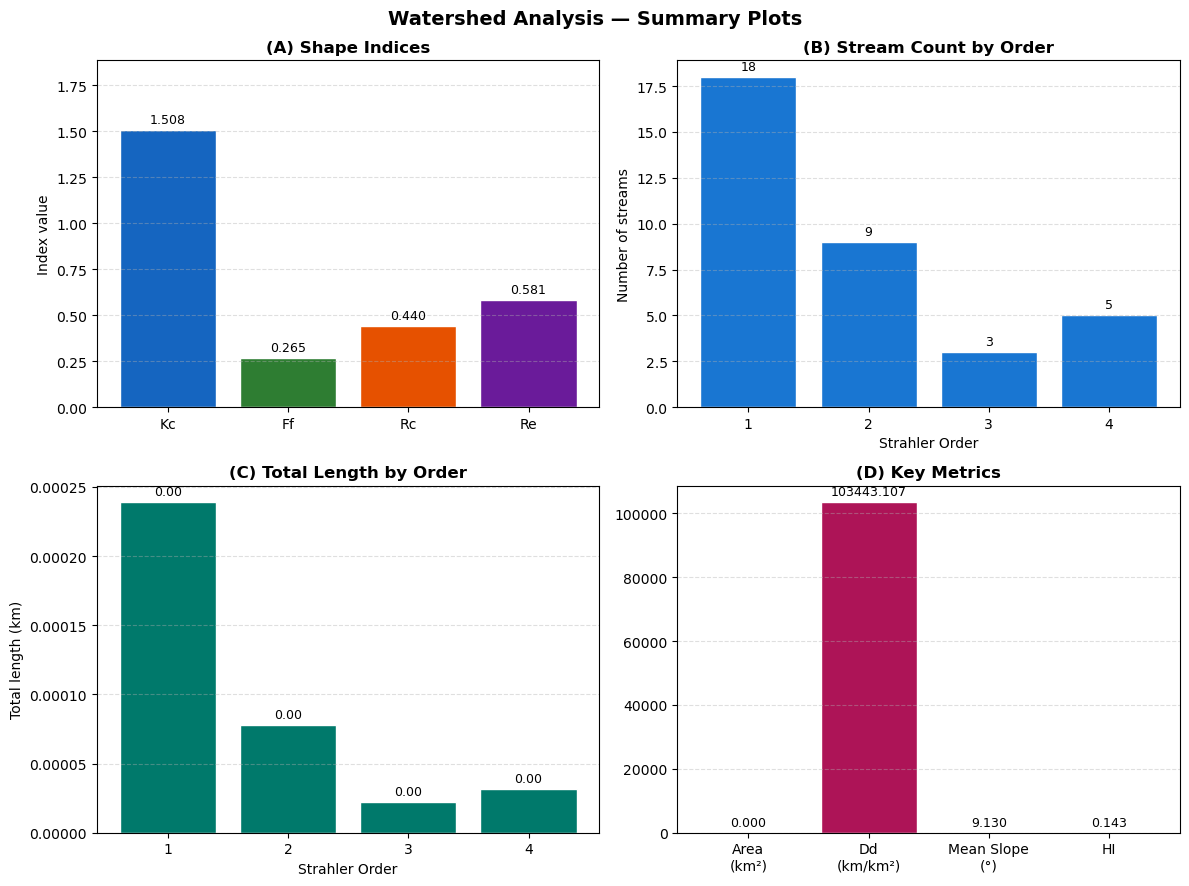

Plot saved to: C:\WatershedProject\outputs\watershed_plots.png


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Watershed Analysis — Summary Plots', fontsize=14, fontweight='bold')
COLORS = ['#1565c0','#2e7d32','#e65100','#6a1b9a']

# (A) Shape indices
ax = axes[0, 0]
idx_keys = ['Compactness Coeff (Kc)','Form Factor (Ff)',
            'Circularity Ratio (Rc)','Elongation Ratio (Re)']
idx_vals = [float(params[k]) for k in idx_keys]
bars = ax.bar(['Kc','Ff','Rc','Re'], idx_vals, color=COLORS, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_title('(A) Shape Indices', fontweight='bold')
ax.set_ylim(0, max(idx_vals) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylabel('Index value')

# (B) Stream count by Strahler order
ax = axes[0, 1]
if not order_df.empty:
    bars = ax.bar(order_df['Order'].astype(str), order_df['N'],
                  color='#1976d2', edgecolor='white')
    ax.bar_label(bars, padding=3, fontsize=9)
else:
    ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
ax.set_title('(B) Stream Count by Order', fontweight='bold')
ax.set_xlabel('Strahler Order'); ax.set_ylabel('Number of streams')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# (C) Total stream length by order
ax = axes[1, 0]
if not order_df.empty:
    bars = ax.bar(order_df['Order'].astype(str), order_df['TotalLen_km'],
                  color='#00796b', edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
else:
    ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
ax.set_title('(C) Total Length by Order', fontweight='bold')
ax.set_xlabel('Strahler Order'); ax.set_ylabel('Total length (km)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# (D) Key metrics
ax = axes[1, 1]
met_keys = ['Watershed Area (km²)','Drainage Density (km/km²)',
            'Mean Slope (°)','Hypsometric Integral']
met_vals = [float(params[k]) for k in met_keys]
met_lbls = ['Area\n(km²)','Dd\n(km/km²)','Mean Slope\n(°)','HI']
bars = ax.bar(met_lbls, met_vals,
              color=['#c62828','#ad1457','#283593','#558b2f'], edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_title('(D) Key Metrics', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plot_out = os.path.join(OUTPUT_DIR, 'watershed_plots.png')
plt.savefig(plot_out, dpi=180, bbox_inches='tight')
plt.show()
print('Plot saved to:', plot_out)

Export Results

In [33]:
# CSV: full parameter table
summary_csv = os.path.join(OUTPUT_DIR, 'watershed_parameters.csv')
pd.DataFrame(params.items(), columns=['Parameter','Value']).to_csv(summary_csv, index=False)
print('Parameter CSV :', summary_csv)

# CSV: stream order table
if not order_df.empty:
    order_csv = os.path.join(OUTPUT_DIR, 'stream_order_summary.csv')
    order_df.to_csv(order_csv, index=False)
    print('Stream order CSV:', order_csv)

# Shapefiles: watershed polygon, clipped streams, projected pour point
shp_dir = os.path.join(OUTPUT_DIR, 'shapefiles')
os.makedirs(shp_dir, exist_ok=True)
for fc in [WS_POLY, STR_CLIP, PP_PROJ]:
    arcpy.conversion.FeatureClassToFeatureClass(fc, shp_dir, os.path.basename(fc))
    print('Shapefile exported:', os.path.basename(fc))

print('\n✅ All exports complete →', OUTPUT_DIR)

Parameter CSV : C:\WatershedProject\outputs\watershed_parameters.csv
Stream order CSV: C:\WatershedProject\outputs\stream_order_summary.csv
Shapefile exported: watershed_polygon
Shapefile exported: stream_clipped
Shapefile exported: pour_point_projected

✅ All exports complete → C:\WatershedProject\outputs


Release License & Summary

In [34]:
# Always release the extension when done
arcpy.CheckInExtension('Spatial')
print('✅ Spatial Analyst extension released.')

print('\n' + '='*52)
print('   AUTOMATED WATERSHED ANALYSIS — COMPLETE')
print('='*52)
print(f'  GDB         : {GDB_PATH}')
print(f'  Outputs     : {OUTPUT_DIR}')
print(f'  Area        : {params["Watershed Area (km²)"]} km²')
print(f'  Relief      : {params["Elevation Relief (m)"]} m')
print(f'  Tc (Kirpich): {params["Time of Concentration (min)"]} min')
print(f'  SCS Q       : {params["SCS Direct Runoff Q (mm)"]} mm  (CN={CURVE_NUMBER}, P={DESIGN_RAINFALL_MM} mm)')
print('='*52)

✅ Spatial Analyst extension released.

   AUTOMATED WATERSHED ANALYSIS — COMPLETE
  GDB         : C:\WatershedProject\outputs\watershed_analysis.gdb
  Outputs     : C:\WatershedProject\outputs
  Area        : 0.0 km²
  Relief      : 89.0 m
  Tc (Kirpich): 0.0 min
  SCS Q       : 41.14 mm  (CN=75, P=100.0 mm)
